In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path

sys.path.append(os.path.abspath(".."))
from src.utils.paths import RAW_DATA_DIR, DATA_DIR

import warnings
warnings.filterwarnings('ignore')

In this demo, we explore the datasets in the "raw_data" folder. There are two types of data:

- **Futures data** (multiple contracts with different expiration dates)

- **AI agent trading data**

Code will not modify any files in the project folder.

# **Futures Data**

The futures data contains 6 columns:
$$
[\text{time, open, high, low, close, volume}]
$$

A key feature of futures is that each contract has a fixed expiration date.

- A contract becomes the front contract when it has the highest liquidity.

- Before becoming the front contract, its volume is very low.

- As it approaches expiration, volume drops sharply as traders roll to the next contract.

For example, the Nasdaq contract NQH20 (March 2020) has high volume roughly from mid-Dec 2019 to mid-Mar 2020, when it is the front contract. Outside this period, trading activity is negligible.

Since multiple contracts with different expiration dates coexist, we need to identify the front-contract period for each contract and stitch these periods together to form a continuous time series.

### **Special Case: Heating Oil**

Heating Oil futures present additional challenges:

- Contracts are listed monthly, leading to more frequent rollovers.

- Identifying the front contract is less clear.

- Some contracts exhibit abnormal early volume (e.g. HOM22 has high volume as early as Oct 2020, far from its June 2022 expiration).

This makes contract selection and filtering more difficult compared to other assets.

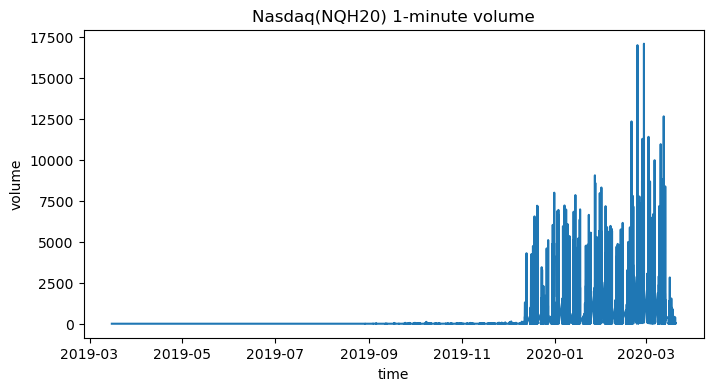

,time,open,high,low,close,volume
104531,2020-03-20 09:25:00,7437.25,7445.75,7432.00,7432.00,10.0
104532,2020-03-20 09:26:00,7438.75,7447.50,7433.75,7437.75,66.0
104533,2020-03-20 09:27:00,7445.00,7445.00,7365.00,7368.50,17.0
104534,2020-03-20 09:28:00,7368.00,7439.00,7368.00,7439.00,13.0
104535,2020-03-20 09:29:00,7450.00,7453.50,7370.00,7453.50,55.0


In [2]:
sample_data=pd.read_csv(RAW_DATA_DIR/'Nasdaq'/'NQH20.csv',header=None)
sample_data.columns=['time','open','high','low','close','volume']
sample_data['time']=pd.to_datetime(sample_data['time'])
sample_data[['open','high','low','close','volume']]=sample_data[['open','high','low','close','volume']].astype(float)

plt.figure(figsize=(8,4))
plt.plot(sample_data['time'],sample_data['volume'])
plt.xlabel('time')
plt.ylabel('volume')
plt.title('Nasdaq(NQH20) 1-minute volume')
plt.show()

sample_data.tail()

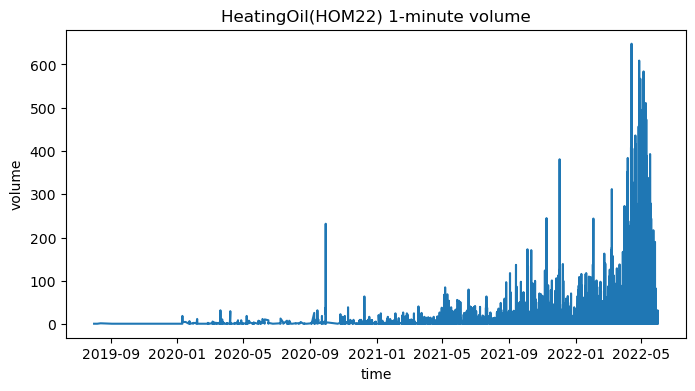

,time,open,high,low,close,volume
72723,2022-05-31 14:25:00,404.08,407.77,403.48,403.48,7.0
72724,2022-05-31 14:26:00,403.75,404.50,403.75,404.50,2.0
72725,2022-05-31 14:27:00,404.50,405.33,404.50,404.50,7.0
72726,2022-05-31 14:28:00,403.34,403.41,402.43,402.76,17.0
72727,2022-05-31 14:29:00,400.00,400.06,398.94,398.94,12.0


In [3]:
sample_data=pd.read_csv(RAW_DATA_DIR/'HeatingOil'/'HOM22.csv',header=None)
sample_data.columns=['time','open','high','low','close','volume']
sample_data['time']=pd.to_datetime(sample_data['time'])
sample_data[['open','high','low','close','volume']]=sample_data[['open','high','low','close','volume']].astype(float)

plt.figure(figsize=(8,4))
plt.plot(sample_data['time'],sample_data['volume'])
plt.xlabel('time')
plt.ylabel('volume')
plt.title('HeatingOil(HOM22) 1-minute volume')
plt.show()

sample_data.tail()

# **AI Agent Data**

The AI agent data contains 5 columns:
$$
[\text{date, hour, minute, price, position}]
$$

Interpretation:

- At each timestamp, the agent observes a price and holds a net position (inventory). 

- The timestamps are in 5-minute intervals. It's unclear whether they are left-inclusive or right-inclusive (this will be discussed later). We treat each timestamp as an instantaneous observation of price. For example, at $t_1=14:05$ the price is $p_1$, and at $t_2=14:10$ the price is $p_2$. These are simply point-in-time price records.

- If the position changes from $q_1$ to $q_2$ between $t_1$ and $t_2$, the trade size is $\Delta q=q_2-q_1$, and the execution price is $p_2$. It implies that at $t_2$,  the agent executes the trade immediately. However, this is not necessary -- we could instead place a limit order based on current market conditions, which may lead to better execution and more effective trading strategies.

- The "date" column may appear as integers (e.g. 43832) due to Excel/CSV formatting issues.

In [4]:
sample_data=pd.read_csv(RAW_DATA_DIR/'Nasdaq'/'AIAgent_Nasdaq.csv',header=None)
sample_data.columns=['date','hour','minute','price','position']
sample_data['date']=pd.to_datetime(sample_data['date'], unit='D', origin='1899-12-30')

sample_data.iloc[25:35]

,date,hour,minute,price,position
25,2020-01-02,2,5,8790.00,0
26,2020-01-02,2,10,8791.25,0
27,2020-01-02,2,15,8790.50,0
28,2020-01-02,2,20,8794.50,0
29,2020-01-02,2,25,8795.25,0
30,2020-01-02,2,30,8795.00,3
31,2020-01-02,2,35,8794.75,3
32,2020-01-02,2,40,8795.50,3
33,2020-01-02,2,45,8796.25,3
34,2020-01-02,2,50,8798.25,3


# **Time Converage**

I'm more familiar with equity data, so I downloaded daily SPX data from yfinance. I then compared the trading dates of the futures data and the AIAgent data with those of the SPX index to check for any missing or extra trading dates.

But before doing this, there is an important issue: futures markets do not follow standard calendar trading hours. Trading typically begins in the late afternoon of one day and ends in the late afternoon of the next day, with a one-hour maintenance break. As a result, the trading dates can include Sundays, which introduces unnecessary complications when aligning with equity data.

To address this, I propose using a trading clock rather than a calendar clock. Specifically, if trading starts at 6:00 PM on day $t$ and ends at 5:00 PM on day $t+1$, we shift the timestamps forward by 6 hours. This effectively maps the trading session to a single calendar day (from 12:00 AM to 11:00 PM), eliminating cross-day overlap.

In practice, this requries identifying the maintenance break (rest hour) for each futures contract and applying the appropriate time shift accordingly.

Note: we don't use a trading clock in this part.

## **Identify maintenance break**

In [4]:
raw_data_path=RAW_DATA_DIR
markets=sorted([p.name for p in raw_data_path.iterdir() if p.is_dir()])

for market in markets:
    print(f'========== {market} ==========')
    market_path=RAW_DATA_DIR/market
    
    files=sorted([p.name for p in market_path.glob("*.csv")
                if not p.name.startswith("AIAgent")])
    ai_file=[p.name for p in market_path.glob("*.csv")
                if p.name.startswith("AIAgent")][0]
    
    full_hours=set(list(range(24)))
    full_minutes=set(list(range(60)))
    hours_set=set()
    volume_list=[]
    
    for file in files:
        data=pd.read_csv(RAW_DATA_DIR/market/file,header=None)
        data=data.dropna() # delete rows with missing value, this doesn't change the results here
        data.columns=['time','open','high','low','close','volume']
        data['time']=pd.to_datetime(data['time'])
        data['hour']=(data['time'].dt.hour).astype(int)
        hours_set=hours_set.union(set([int(h) for h in data['hour'].unique()]))
        
        data=data.set_index('time')
        volume_series=data['volume']
        volume_series.name=file[:-4]
        volume_list.append(volume_series)
    
    # futures missing hour 
    print(f'futures missing hours: {sorted(list(full_hours-hours_set))}')
    
    # agent missing hour
    data=pd.read_csv(RAW_DATA_DIR/market/ai_file,header=None)
    data.columns=['date','hour','minute','price','position']
    hours_set=set([int(h) for h in data['hour'].unique()])
    print(f'AIAgent missing hours: {sorted(list(full_hours-hours_set))}')
    
    # futures missing minute
    time_df=pd.concat(volume_list,axis=1,join='outer')
    time_df=time_df.reset_index()
    time_df['time']=pd.to_datetime(time_df['time'])
    time_df['hour']=(time_df['time'].dt.hour).astype(int)
    time_df['minute']=(time_df['time'].dt.minute).astype(int)
    
    print('futures missing minutes:')
    hours=[int(h) for h in time_df['hour'].unique()]
    for h in hours:
        temp=time_df[time_df['hour']==h]
        missing=full_minutes-set(temp['minute'].unique())
        if len(missing)>0:
            print(f'hour={h}, {len(missing)} missing minutes: {missing}')

========== EuroStoxx ==========
futures missing hours: [18]
AIAgent missing hours: []
futures missing minutes:
hour=19, 14 missing minutes: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13}
hour=17, 58 missing minutes: {0, 1, 2, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59}
========== GBP - British Pound ==========
futures missing hours: [17]
AIAgent missing hours: []
futures missing minutes:
========== German Bunds - German Government Bonds ==========
futures missing hours: [18]
AIAgent missing hours: []
futures missing minutes:
hour=19, 15 missing minutes: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14}
hour=17, 59 missing minutes: {0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 5

From the result we can see that:

- Nasdaq, JPY, HeatingOil, Gold, GBP's maintenance hour is 5:00PM-6:00PM, and Nasdaq has another short break: 4:15PM-4:30PM

- EuroStoxx and German Bunds's maintenance hour seems to be 6:00PM-7:00PM, but if we look deeper at the minute level, 5:00PM-6:00PM also misses almost all the timestamp, so we believe that the maintenance is still 5:00PM-6:00PM, and we don't have data between 6:00PM-7:00PM.

## **Does raw data have missing/extra trading dates?**

In [5]:
import yfinance as yf
    
spx = yf.download(
    "^SPX",
    start="2016-01-01",
    auto_adjust=True,
    progress=False,
    group_by="column",
    threads=True
)

spx.columns = spx.columns.get_level_values(0)
spx = spx[['Close']].rename(columns={'Close': 'spx'})
spx.reset_index(inplace=True)
spx.columns.name=None
spx.columns=['date','spx']
spx['date']=pd.to_datetime(spx['date'])

spx.head()

,date,spx
0,2016-01-04,2012.660034
1,2016-01-05,2016.709961
2,2016-01-06,1990.260010
3,2016-01-07,1943.089966
4,2016-01-08,1922.030029


In [6]:
raw_data_path=RAW_DATA_DIR
markets=sorted([p.name for p in raw_data_path.iterdir() if p.is_dir()])
hour_adjust=6

for market in markets:
    print(f'========== {market} ==========')
    market_path=RAW_DATA_DIR/market
    
    ai_file=[p.name for p in market_path.glob("*.csv")
                if p.name.startswith("AIAgent")][0]
    
    # AI agent data
    data=pd.read_csv(RAW_DATA_DIR/market/ai_file,header=None)
    data.columns=['date','hour','minute','price','position']
    data['date']=pd.to_datetime(data['date'], unit='D', origin='1899-12-30')
    data['time'] = (data['date']
                    + pd.to_timedelta(data['hour'], unit='h') 
                    + pd.to_timedelta(data['minute'], unit='m'))
    data['time']=data['time']+pd.Timedelta(hours=hour_adjust)
    data['date']=pd.to_datetime(data['time'].dt.date)
    data['trade']=data['position'].diff().abs()
    data=data.groupby('date')[['trade']].sum()
    
    spx_temp=spx[(spx['date']>=data.index[0])&(spx['date']<=data.index[-1])]
    spx_temp=spx_temp.set_index('date')
    
    temp=spx_temp.loc[~spx_temp.index.isin(data.index)]
    if len(temp)==0:
        print('Agent data includes all normal trading dates')
    
    data=data.loc[~data.index.isin(spx_temp.index)]
    if len(data)>0:
        print('Agent data contains weekends or holidays')
        data=data.reset_index()
        data['date']=pd.to_datetime(data['date'])
        data['weekdays']=data['date'].dt.day_name()
        result=data.groupby('weekdays')['trade'].sum()
        print(result)

========== EuroStoxx ==========
Agent data includes all normal trading dates
Agent data contains weekends or holidays
weekdays
Friday    3.0
Monday    7.0
Name: trade, dtype: float64
========== GBP - British Pound ==========
Agent data includes all normal trading dates
Agent data contains weekends or holidays
weekdays
Friday    12.0
Monday    41.0
Name: trade, dtype: float64
========== German Bunds - German Government Bonds ==========
Agent data includes all normal trading dates
Agent data contains weekends or holidays
weekdays
Friday      12.0
Monday      11.0
Thursday    22.0
Name: trade, dtype: float64
========== Gold ==========
Agent data includes all normal trading dates
Agent data contains weekends or holidays
weekdays
Friday     3.0
Monday    38.0
Name: trade, dtype: float64
========== HeatingOil ==========
Agent data includes all normal trading dates
Agent data contains weekends or holidays
weekdays
Friday     5.0
Monday    13.0
Name: trade, dtype: float64
========== JPY - Japa

From the results, we observe that

- All agent datasets include normal trading days, but they also include extra trading dates.

- Those extra trading dates are holidays, and agent sometimes trades on holidays.

- This is becasue, during certain holidays, equity markets are closed while futures markets may remain open for limited trading hours (e.g., half-day sessions).

In [7]:
raw_data_path=RAW_DATA_DIR
markets=sorted([p.name for p in raw_data_path.iterdir() if p.is_dir()])
hour_adjust=6

for market in markets:
    print(f'========== {market} ==========')
    market_path=RAW_DATA_DIR/market
    
    files=sorted([p.name for p in market_path.glob("*.csv")
                if not p.name.startswith("AIAgent")])
    ai_file=[p.name for p in market_path.glob("*.csv")
             if p.name.startswith("AIAgent")][0]
        
    # AI agent data
    ai_data=pd.read_csv(RAW_DATA_DIR/market/ai_file,header=None)
    ai_data.columns=['date','hour','minute','price','position']
    ai_data['date']=pd.to_datetime(ai_data['date'], unit='D', origin='1899-12-30')
    ai_data['time'] = (ai_data['date']
                    + pd.to_timedelta(ai_data['hour'], unit='h') 
                    + pd.to_timedelta(ai_data['minute'], unit='m'))
    ai_data['time']=ai_data['time']+pd.Timedelta(hours=hour_adjust)
    ai_data['date']=pd.to_datetime(ai_data['time'].dt.date)
    ai_dates=set(ai_data['date'].unique())
    start_date=ai_data['date'].iloc[0]
    end_date=ai_data['date'].iloc[-1]
    
    # futures data
    dates=set()
    for file in files:
        data=pd.read_csv(RAW_DATA_DIR/market/file,header=None)
        data=data.dropna() # delete rows with missing value, this doesn't change the results here
        data.columns=['time','open','high','low','close','volume']
        data['time']=pd.to_datetime(data['time'])+pd.Timedelta(hours=hour_adjust)
        data['date']=pd.to_datetime(data['time'].dt.date)
        data=data[(data['date']>=start_date)&(data['date']<=end_date)]
        dates=dates.union(set(data['date'].unique()))
        
    if ai_dates==dates:
        print('Futures data and Agent data have same trading dates')
    elif dates.issubset(ai_dates):
        print('Futures trading dates is a subset of Agent trading dates')
    else:
        print('No')

========== EuroStoxx ==========
Futures trading dates is a subset of Agent trading dates
========== GBP - British Pound ==========
Futures trading dates is a subset of Agent trading dates
========== German Bunds - German Government Bonds ==========
Futures data and Agent data have same trading dates
========== Gold ==========
Futures trading dates is a subset of Agent trading dates
========== HeatingOil ==========
Futures trading dates is a subset of Agent trading dates
========== JPY - Japanese Yen ==========
Futures trading dates is a subset of Agent trading dates
========== Nasdaq ==========
Futures trading dates is a subset of Agent trading dates


From the result, we observe that 

- Futures trading dates is a subset of Agent trading dates

- We will use Agent trading dates as benchmark trading dates.

# **Left or Right inclusive?**

From the PDF file, we can know clearly that the 1 minute data of futures are left-inclusive. For example, 9:00 AM's correponding OHLC are observed during the interval [9:00, 9:01), rather than (8:59, 9:00].

However, whether the timestamp in agent data is right or left inclusive is unknown. But we can do an experiment. If it is right-inclusive, the price at 9:00 will be the close price of the 5-minute interval (8:55, 9:00], then we compare it with close price at the timestamp 8:59 of the futures data; if it is left-inclusive, the price at 9:00 will be the open price of [9:00, 9:05), then we compare it with open price at 9:00 at futures data. 

The result shows that the first situion is true -- the timestamp in agent data is right-inclusive.

One example: Look at Nasdaq agent data at 2020-01-02 00:35, the price is 8784.00. But the open price of NQH20 at 00:35 is 8784.25, while the close price of NQH20 at 00:34 is 8784.00. The equal close price at 00:34 and different open price at 00:35 proves the logic.

After figuring out the exact meaning of the data, we need to resample the futures data into 5-minute frequncy, because this is the frequency of agent data. Then we can construct our trading rules and compare then with agent benchmark.

But here comes the problem of benckmark trading time again. We already know for dates, we can use agent trading dates because it contains all trading dates. But for hours and minutes, is agent still a good benchmark?

## **Does agent data have missing trading hours/minutes?**

In [8]:
raw_data_path=RAW_DATA_DIR
markets=sorted([p.name for p in raw_data_path.iterdir() if p.is_dir()])

missing_dict=dict()
full_expected_times = pd.date_range(start="00:05",end="23:00",freq="5min").time

for market in markets:
    print(f'======== {market} ========')
    market_path=raw_data_path/market
    
    ai_file=[p.name for p in market_path.glob("*.csv")
                if p.name.startswith("AIAgent")][0]

    # agent_data
    agent_df=pd.read_csv(RAW_DATA_DIR/market/ai_file,header=None)
    agent_df.columns=['date','hour','minute','price','position']
    agent_df['date']=pd.to_datetime(agent_df['date'], unit='D', origin='1899-12-30')
    agent_df['time'] = (agent_df['date']
                        + pd.to_timedelta(agent_df['hour'], unit='h') 
                        + pd.to_timedelta(agent_df['minute'], unit='m'))
    # 1. add 6 hours
    agent_df['time']=pd.to_datetime(agent_df['time']) + pd.Timedelta(hours=6)
    # 2. delete Saturday & Sunday
    agent_df['weekday']=agent_df['time'].dt.day_name()
    agent_df = agent_df[~agent_df['weekday'].isin(['Saturday', 'Sunday'])].copy()
    # 3. delete closing period
    agent_df['hour'] = agent_df['time'].dt.hour
    agent_df['minute'] = agent_df['time'].dt.minute
    agent_df = agent_df[
        (
            (agent_df['hour'] > 0) | (agent_df['minute'] >= 5)   # remove 00:00
        )
        &
        (
            (agent_df['hour'] < 23) | ((agent_df['hour'] == 23) & (agent_df['minute'] == 0))
        )
    ].copy()
    # 4. check missing timestamps per day
    
    agent_df['date'] = agent_df['time'].dt.date
    all_dates = sorted(agent_df['date'].unique())
    
    summary_rows = []

    for d in all_dates:
        day_df = agent_df[agent_df['date'] == d].copy()
        actual_times = sorted(day_df['time'].dt.time.tolist())
        actual_count = len(actual_times)

        first_obs = actual_times[0]
        last_obs = actual_times[-1]

        if d == all_dates[0] and d == all_dates[-1]:
            # only one date in the whole dataset
            expected_times = pd.date_range(
                start=pd.Timestamp.combine(pd.Timestamp(d), first_obs),
                end=pd.Timestamp.combine(pd.Timestamp(d), last_obs),
                freq="5min"
            ).time

        elif d == all_dates[0]:
            # first date: start from first observed time, end at 23:00
            expected_times = pd.date_range(
                start=pd.Timestamp.combine(pd.Timestamp(d), first_obs),
                end=pd.Timestamp.combine(pd.Timestamp(d), pd.Timestamp("23:00").time()),
                freq="5min"
            ).time

        elif d == all_dates[-1]:
            # last date: start at 00:05, end at last observed time
            expected_times = pd.date_range(
                start=pd.Timestamp.combine(pd.Timestamp(d), pd.Timestamp("00:05").time()),
                end=pd.Timestamp.combine(pd.Timestamp(d), last_obs),
                freq="5min"
            ).time

        else:
            # middle dates: full range
            expected_times = full_expected_times

        expected_count = len(expected_times)
        missing_count = expected_count - actual_count

        summary_rows.append({
            'date': d,
            'actual': actual_count,
            'expected': expected_count,
            'missing': missing_count,
            'first_obs': first_obs,
            'last_obs': last_obs,
        })

    missing_summary = pd.DataFrame(summary_rows).set_index('date')
    missing_dict[market] = missing_summary
    print(f'number of missing timestamps: {missing_summary['missing'].sum()}')

======== EuroStoxx ========
number of missing timestamps: 0
======== GBP - British Pound ========
number of missing timestamps: 0
======== German Bunds - German Government Bonds ========
number of missing timestamps: 0
======== Gold ========
number of missing timestamps: 0
======== HeatingOil ========
number of missing timestamps: 0
======== JPY - Japanese Yen ========
number of missing timestamps: 0
======== Nasdaq ========
number of missing timestamps: 0


From the result we can observe that agent data is a good trading time benchmark.

# **Data Cleaning Objectives**

Now we have gained some knowledges about futures and agent data. It's time to confirm how to do the data cleaning.

For futures datasets:

1. Remove low-activity periods with negligible trading volume

2. Identify the front contract for each time period

3. Stitch the front contracts together to construct a continuous futures series

4. Implement a resmaple function to aggregagte 1-minute data into lower frequencies (e.g., 5-minute, 30-minute, and 1-hour intervals).

For AIAgent data:

1. Compute the trading volume series (it's simply the difference between adjenct net positions)

2. construct the benchmark PnL

The most difficult part is step 2 of cleaning futrues datasets: identify the front contracts for each time period. There are two approaches:

1. find a criteria by ourself, such as using volume to decide which is the front contract.

2. find the information inside the agent data. This is our benchmark, we need to use the same trading information as agent data (trading how many at what time). At each timestamp, we compare the price of agent data and the price of different contracts, choose the contract with the same price. If there are missing timestamps for futures or multiple contracts have the same price, we use continous property of front month contracts: in certain periods, there is only one front contract, it can not jump from one to another frequently. Fortunately, results shows these situations usually happens in the middle of the front contract period, so we can use continuous property to solve.

The second method is the most rigorous method, because if we want to compare our trading rule with agent's trading rule, we need to make sure that other factors are the same, which includes the choice of front month contract.

But we will compare the result of these two methods, see if the difference is large. If it is large, we know the agent might use another way to choose the front contract, if not large, we can believe that agent also use this method to choose front contract.